In [1]:
!pip install xgboost
!pip install shap


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


# Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor, plot_importance
import shap

In [4]:
df = pd.read_csv('../data/food_delivery.csv')

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [7]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64


In [8]:
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41359 non-null  object 
 1   Delivery_person_ID           41359 non-null  object 
 2   Delivery_person_Age          41359 non-null  float64
 3   Delivery_person_Ratings      41359 non-null  float64
 4   Restaurant_latitude          41359 non-null  float64
 5   Restaurant_longitude         41359 non-null  float64
 6   Delivery_location_latitude   41359 non-null  float64
 7   Delivery_location_longitude  41359 non-null  float64
 8   Order_Date                   41359 non-null  object 
 9   Time_Orderd                  41359 non-null  object 
 10  Time_Order_picked            41359 non-null  object 
 11  Weather_conditions           41359 non-null  object 
 12  Road_traffic_density         41359 non-null  object 
 13  Vehicle_condition    

In [10]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')

In [11]:
df = df.dropna(subset=['Time_Order_picked'])

In [12]:
print(df['Time_Order_picked'].isnull().sum()) 
print(df.shape)  

0
(41359, 20)


In [13]:
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce').dt.time

/var/folders/z3/wpy7_z4x3595fd3q4jhrrp0w0000gn/T/ipykernel_94405/2504524308.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce').dt.time


In [14]:
df['Time_Ordered'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M', errors='coerce').dt.time

In [15]:
df.drop(['Time_Orderd'],axis=1,inplace=True)

In [16]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Time_Ordered
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,22:10:00,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,21:55:00
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,15:05:00,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,14:55:00
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:40:00,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,17:30:00
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:30:00,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,09:20:00
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,20:05:00,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19:50:00


In [17]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of Earth in km
    return c * r

df['Distance (km)'] = df.apply(lambda row: haversine(
    row['Restaurant_latitude'], row['Restaurant_longitude'],
    row['Delivery_location_latitude'], row['Delivery_location_longitude']), axis=1)


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
df['prep_time'] = (
    pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce') -
    pd.to_datetime(df['Time_Ordered'], format='%H:%M:%S', errors='coerce')
).dt.total_seconds() / 60
df['hour_of_day'] = pd.to_datetime(df['Time_Ordered'], format='%H:%M:%S', errors='coerce').dt.hour


In [20]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features

label_encoders = {}

# Loop through all object columns
for col in df.select_dtypes(include='object').columns:
    if df[col].apply(lambda x: isinstance(x, str)).all():  # Encode only pure strings
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    else:
        print(f"Skipped column: {col} (Not pure string or contains NaT/time)")


Skipped column: Time_Order_picked (Not pure string or contains NaT/time)
Skipped column: Time_Ordered (Not pure string or contains NaT/time)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41359 non-null  int64         
 1   Delivery_person_ID           41359 non-null  int64         
 2   Delivery_person_Age          41359 non-null  float64       
 3   Delivery_person_Ratings      41359 non-null  float64       
 4   Restaurant_latitude          41359 non-null  float64       
 5   Restaurant_longitude         41359 non-null  float64       
 6   Delivery_location_latitude   41359 non-null  float64       
 7   Delivery_location_longitude  41359 non-null  float64       
 8   Order_Date                   41359 non-null  datetime64[ns]
 9   Time_Order_picked            36833 non-null  object        
 10  Weather_conditions           41359 non-null  int64         
 11  Road_traffic_density         41359 non-null  i

In [22]:
df.drop(['ID','Delivery_person_ID','Delivery_person_Age','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude'],axis=1,inplace=True)

In [23]:
df.dropna(inplace = True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33402 entries, 0 to 45583
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Delivery_person_Ratings  33402 non-null  float64       
 1   Order_Date               33402 non-null  datetime64[ns]
 2   Time_Order_picked        33402 non-null  object        
 3   Weather_conditions       33402 non-null  int64         
 4   Road_traffic_density     33402 non-null  int64         
 5   Vehicle_condition        33402 non-null  int64         
 6   Type_of_order            33402 non-null  int64         
 7   Type_of_vehicle          33402 non-null  int64         
 8   multiple_deliveries      33402 non-null  float64       
 9   Festival                 33402 non-null  int64         
 10  City                     33402 non-null  int64         
 11  Time_taken (min)         33402 non-null  int64         
 12  Time_Ordered             33402 non-nu

In [25]:
import pandas as pd

# This will automatically handle both 'HH:MM' and 'HH:MM:SS' formats
df['Time_Ordered'] = pd.to_datetime(df['Time_Ordered'], format='mixed', errors='coerce').dt.time
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='mixed', errors='coerce').dt.time


In [26]:
df.drop(['Time_Ordered', 'Time_Order_picked'], axis=1, inplace=True)


In [27]:
# Convert datetime column to numeric features
df['Order_Weekday'] = df['Order_Date'].dt.weekday

# Drop original datetime columns
df.drop(columns=['Order_Date'], inplace=True)


In [28]:
df

,Delivery_person_Ratings,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Distance (km),prep_time,hour_of_day,Order_Weekday
0,4.2,1,1,2,3,1,3.0,0,0,46,10.280582,15.0,21.0,5
1,4.7,3,0,1,2,1,1.0,0,0,23,6.242319,10.0,14.0,6
2,4.7,2,3,1,1,2,1.0,0,0,21,13.787860,10.0,17.0,4
3,4.3,2,2,0,0,1,0.0,0,0,20,2.930258,10.0,9.0,6
4,4.7,1,1,1,3,2,1.0,0,0,41,19.396618,15.0,19.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45578,4.2,5,1,2,1,1,1.0,0,0,33,16.600272,10.0,21.0,1
45579,4.8,5,0,1,2,1,0.0,0,0,32,1.489846,10.0,11.0,3
45580,4.6,5,1,0,0,1,1.0,0,0,36,11.007735,15.0,19.0,2
45582,4.7,0,0,0,3,1,1.0,0,0,26,6.232393,5.0,13.0,0


In [29]:
df.drop(columns = ['Type_of_order','Type_of_vehicle','Order_Weekday'],inplace = True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33402 entries, 0 to 45583
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Delivery_person_Ratings  33402 non-null  float64
 1   Weather_conditions       33402 non-null  int64  
 2   Road_traffic_density     33402 non-null  int64  
 3   Vehicle_condition        33402 non-null  int64  
 4   multiple_deliveries      33402 non-null  float64
 5   Festival                 33402 non-null  int64  
 6   City                     33402 non-null  int64  
 7   Time_taken (min)         33402 non-null  int64  
 8   Distance (km)            33402 non-null  float64
 9   prep_time                33402 non-null  float64
 10  hour_of_day              33402 non-null  float64
dtypes: float64(5), int64(6)
memory usage: 3.1 MB


In [31]:
X = df.drop(['Time_taken (min)'], axis=1)
y = df['Time_taken (min)']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

MAE: 3.89
R² Score: 0.72


# Hyperparameter Tuning 

In [35]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("MAE : ", mean_absolute_error(y_test,y_pred))
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

MAE :  3.7972178131569434
R² Score: 0.74


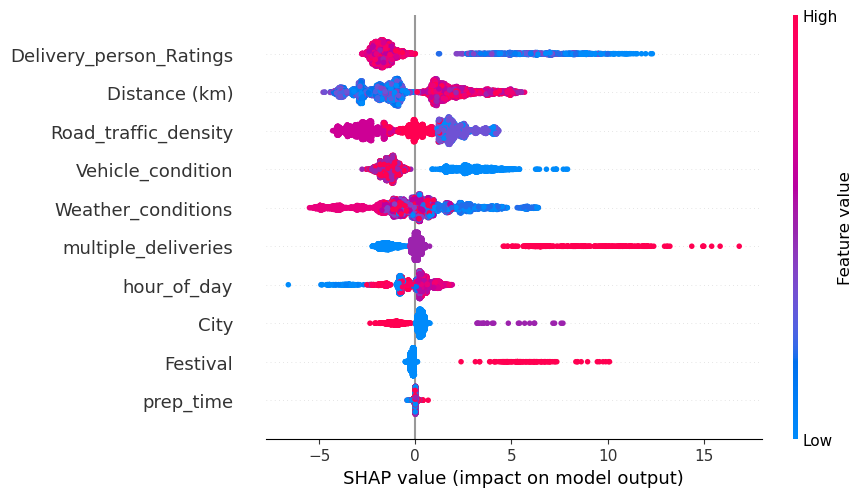

In [36]:
import shap

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [38]:
import pickle

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)